## Problem Statement

To analyze the factors influencing the resale price of used bikes by examining features such as brand, model year, kilometers driven, ownership, and listing type using data scraped from the Bikes4Sale website. The analysis aims to identify the key factors that affect bike prices and provide meaningful insights for buyers and sellers.

In [1]:
import requests
import re
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bikes = []
txt_boxes = []
for page_no in range(1,12):     
    url = f"https://www.bikes4sale.in/used/buy/?page={page_no}"

    page = requests.get(url)
    soup = BeautifulSoup(page.text)

    bike_list = soup.find_all("div", class_="boxRow")
    bikes.extend(bike_list)

    f = soup.find_all("div", class_="txtBox")
    txt_boxes.extend(f)

print(len(bikes))
print(len(txt_boxes))
bikes

469
469


[<div class="boxRow">
         <div class="imgBox"><a href="/used/buy/ktm-duke-duke-200-abs-in-tiruchirappalli/985502/" rel="nofollow" target="_blank"><img alt="KTM Duke 200 ABS 2025 Model" decoding="async" loading="lazy" src="/photos-2/985/985502/ktm-duke-200-abs-1785398864-200.jpeg"/></a>
         </div>
         <div class="txtBox">
           KTM Duke 200 ABS, 2025 Model<br/>Location: Tiruchirappalli, Tamil Nadu<br/><span class="prz">Rs. 2,10,000</span><br/>
           <div class="dlrImp rtoLoan">
             <p><span class="glyphicon glyphicon-ok"></span> Finance Available 
             </p>
           </div>
           
           <a href="/used/buy/ktm-duke-duke-200-abs-in-tiruchirappalli/985502/" rel="nofollow" target="_blank">View More Details</a>
         </div>
       </div>,
 <div class="boxRow">
         <div class="imgBox"><a href="/used/buy/bicycle-hercules-in-hyderabad/985739/" rel="nofollow" target="_blank"><img alt="Bicycle Hercules 2026 Model" decoding="async" loadi

In [3]:
features=[]
for i in txt_boxes:
    features.append(" ".join(i.text.split()))
features

['KTM Duke 200 ABS, 2025 ModelLocation: Tiruchirappalli, Tamil NaduRs. 2,10,000 Finance Available View More Details',
 'Bicycle Hercules, 2026 ModelLocation: Hyderabad, TelanganaRs. 4,800 View More Details',
 'KTM 250 Adventure 2025, 2026 ModelLocation: Tamil NaduRs. 2,75,000 Finance Available View More Details',
 'Keeway K-Light 250V, 2022 ModelLocation: Chennai, Tamil NaduRs. 2,50,000 Finance Available View More Details',
 'Royal Enfield Meteor 350 Stellar, 2022 ModelLocation: Dehradun, UtarakhandRs. 1,75,000 Finance Available View More Details',
 'Honda CB200X, 2023 ModelLocation: North 24 Parganas, West BengalRs. 1,20,000 Finance Available View More Details',
 'Bajaj, 2017 ModelLocation: Haripad, Alappuzha, KeralaRs. 70,000 Finance Available View More Details',
 'Royal Enfield Super Meteor 650, 2024 ModelLocation: Bangalore, KarnatakaRs. 3,90,000 Finance Available View More Details',
 'Hero Xtreme 125R, 2024 ModelLocation: Noida, Uttar PradeshRs. 70,000 Finance Available View More 

In [4]:
brand=[]
for i in features:
    if i.startswith("Royal Enfield"):
        brand.append("Royal Enfield")
    else:
        brand.append(i.split()[0])
brand

['KTM',
 'Bicycle',
 'KTM',
 'Keeway',
 'Royal Enfield',
 'Honda',
 'Bajaj,',
 'Royal Enfield',
 'Hero',
 'Royal Enfield',
 'Kawasaki',
 'Bajaj',
 'Yamaha',
 'Yamaha',
 'Honda',
 'Bicycle',
 'Honda',
 'Hero',
 'TVS',
 'Royal Enfield',
 'Jawa',
 'Royal Enfield',
 'KTM',
 'Odysse',
 'KTM',
 'Royal Enfield',
 'Bajaj',
 'Yamaha',
 'Ampere',
 'EMotorad',
 'Ola',
 'Suzuki',
 'Triumph',
 'BMW',
 'KTM',
 'Royal Enfield',
 'Yamaha',
 'Ola',
 'Jawa',
 'Bajaj',
 'Honda',
 'Honda',
 'Honda',
 'Bajaj',
 'Yamaha',
 'Royal Enfield',
 'Royal Enfield',
 'Royal Enfield',
 'TVS',
 'Ola',
 'Aprilia',
 'Honda',
 'Suzuki',
 'Royal Enfield',
 'Royal Enfield',
 'Bajaj',
 'Bajaj',
 'Bajaj',
 'Royal Enfield',
 'Triumph',
 'Bajaj',
 'Bajaj',
 'Jawa',
 'Revolt',
 'Yamaha',
 'Bajaj',
 'Bajaj',
 'Bajaj',
 'Hero',
 'Bajaj',
 'Yamaha',
 'Yamaha',
 'Okinawa',
 'Bajaj',
 'Honda',
 'Bicycle',
 'Honda',
 'Honda',
 'Hero',
 'Honda',
 'TVS',
 'Royal Enfield',
 'TVS',
 'Royal Enfield',
 'Jawa',
 'Ola',
 'Yezdi',
 'Royal Enf

In [5]:
bike_name=[]
for i in range(len(features)):
    name = features[i].replace(brand[i], "", 1)
    name = name.split("Location:")[0]
    name = re.sub(r",\s*\d{4}\s*Model", "", name)
    bike_name.append(name.strip())

bike_name

['Duke 200 ABS',
 'Hercules',
 '250 Adventure 2025',
 'K-Light 250V',
 'Meteor 350 Stellar',
 'CB200X',
 '2017 Model',
 'Super Meteor 650',
 'Xtreme 125R',
 'Super Meteor 650',
 'Ninja 300R',
 'Pulsar 150 Neon',
 'Alpha',
 'YZF R15 V3 BS6',
 'Activa 6G Std',
 'Schnell',
 'Hness CB350 DLX Pro 2025',
 'Xpulse 200 4V 2023 Edition',
 'Apache RR 310 BTO',
 'Classic 350',
 '42 Dual Tone',
 'Super Meteor 650',
 'RC 200 2020',
 'Evoqis',
 'RC 200 2022',
 'Meteor 350 Fireball',
 'Avenger Street 220',
 'FZ-S FI Ver 4.0',
 'Magnus Ex',
 'Doodle',
 'S1 Pro',
 'Gixxer SF Moto GP',
 'Scrambler 400 X',
 'G 310 RR',
 'Duke 390',
 'Classic Desert Storm',
 'Aerox 155',
 'S1 Pro',
 '42 Bobber Black Mirror',
 'Avenger Street 220',
 'NX500',
 'CB Unicorn',
 'Activa 6G',
 'XCD 125 DTS-Si',
 'YZF R15 V2',
 'Bullet Standard 350',
 'Classic 500',
 'Super meteor 650',
 'Ronin SS',
 'S1 Pro',
 'Tuono 457',
 'Hness CB350 DLX',
 'Intruder 150 FI',
 'Classic Desert Storm',
 'Scram 411',
 'Pulsar 200 NS',
 'Discover

In [6]:
loc=[]
for i in range(len(features)):
    l=features[i].split('Location:')[1]
    l=re.sub("Rs\..*","",l).strip()
    loc.append(l)
loc

['Tiruchirappalli, Tamil Nadu',
 'Hyderabad, Telangana',
 'Tamil Nadu',
 'Chennai, Tamil Nadu',
 'Dehradun, Utarakhand',
 'North 24 Parganas, West Bengal',
 'Haripad, Alappuzha, Kerala',
 'Bangalore, Karnataka',
 'Noida, Uttar Pradesh',
 'Karkala, Udupi, Karnataka',
 'Gorakhpur, Uttar Pradesh',
 'Barasat, North 24 Parganas, West Bengal',
 'Whitefield, Bangalore, Karnataka',
 'Dwarka, South West Delhi, Delhi',
 'Kolkata, West Bengal Finance Available View More Details',
 'Rangareddy, Telangana',
 'Hadapsar, Pune, Maharashtra',
 'Hyderabad, Telangana',
 'Howrah, West Bengal',
 'Jaipur, Rajasthan',
 'Udaipur, Rajasthan',
 'Mayur Vihar, East Delhi, Delhi',
 'Dadar, Mumbai, Maharashtra',
 'Ahmedabad, Gujarat',
 'Kanchipuram, Tamil Nadu',
 'Sholinganallur, Chennai, Tamil Nadu',
 'Gurgaon, Haryana',
 'Banashankari, Bangalore, Karnataka',
 'KR Puram, Bangalore, Karnataka',
 'Whitefield, Bangalore, Karnataka',
 'Nelamangala, Bangalore, Karnataka',
 'Chembur, Mumbai, Maharashtra Finance Availabl

In [7]:
price=[]
for i in range(len(features)):
    match = re.search(r"Rs\.\s*([\d,]+)", features[i])
    
    if match:
        price.append(match.group(1))
    else:
        price.append(None)
price

['2,10,000',
 '4,800',
 '2,75,000',
 '2,50,000',
 '1,75,000',
 '1,20,000',
 '70,000',
 '3,90,000',
 '70,000',
 '4,85,000',
 '3,00,000',
 '35,000',
 '35,000',
 '80,000',
 None,
 '4,500',
 '2,25,000',
 '94,000',
 '2,30,000',
 '1,10,000',
 '1,60,000',
 '3,95,000',
 '1,40,000',
 '80,000',
 '1,80,000',
 '1,60,000',
 '45,000',
 '1,11,000',
 '95,000',
 '50,000',
 '52,000',
 None,
 '2,70,000',
 '3,30,000',
 '1,50,000',
 '90,000',
 '1,25,000',
 '75,000',
 '1,95,000',
 '30,000',
 '6,00,000',
 '55,000',
 '59,000',
 '30,000',
 '45,000',
 '1,60,000',
 '1,00,000',
 '3,60,000',
 '1,40,000',
 '45,000',
 '4,00,000',
 '1,60,000',
 '72,500',
 '2,19,999',
 '1,65,000',
 '1,00,000',
 '35,000',
 '60,000',
 '1,80,000',
 '2,70,000',
 '65,000',
 '75,000',
 '2,50,000',
 '65,000',
 '48,000',
 '70,000',
 '55,000',
 '35,000',
 '40,000',
 '35,000',
 '35,000',
 '80,000',
 '34,000',
 '30,000',
 None,
 '4,500',
 '1,50,000',
 '2,25,000',
 '94,000',
 '75,000',
 '2,30,000',
 '1,00,000',
 '65,000',
 '1,10,000',
 '1,60,000'

In [8]:
model_yr=[]
for i in range(len(features)):
    match = re.search(r"\,\s*([\d]+) Model", features[i])
    if match:
        model_yr.append(match.group(1))
    else:
        model_yr.append(None)
model_yr

['2025',
 '2026',
 '2026',
 '2022',
 '2022',
 '2023',
 '2017',
 '2024',
 '2024',
 '2024',
 '2026',
 '2019',
 '2016',
 '2020',
 '2020',
 '2017',
 '2025',
 '2023',
 '2023',
 '2016',
 '2023',
 '2025',
 '2020',
 '2023',
 '2022',
 '2021',
 '2016',
 '2024',
 '2023',
 '2026',
 '2022',
 '2018',
 '2025',
 '2025',
 '2017',
 '2012',
 '2023',
 '2024',
 '2023',
 '2018',
 None,
 '2010',
 '2022',
 '2008',
 '2013',
 '1994',
 None,
 '2025',
 '2026',
 '2022',
 '2025',
 '2023',
 '2022',
 '2023',
 '2023',
 '2018',
 '2014',
 '2021',
 '2026',
 '2026',
 '2018',
 '2019',
 '2025',
 '2022',
 '2015',
 '2022',
 '2017',
 '2017',
 '2015',
 '2019',
 '2016',
 '2020',
 '2021',
 '2017',
 '2020',
 '2017',
 '2023',
 '2025',
 '2023',
 '2021',
 '2023',
 '2007',
 '2022',
 '2016',
 '2023',
 '2023',
 '2022',
 '2025',
 '2017',
 '2020',
 '2012',
 '2022',
 '2022',
 '2019',
 '2025',
 '2012',
 '2017',
 '2018',
 '2017',
 '2020',
 '2024',
 '2016',
 '2018',
 '2023',
 '2019',
 '2023',
 '2025',
 '2021',
 '2022',
 '2020',
 '2023',
 '202

In [9]:
links=[]
for i in bikes:
    a = i.find("a")
    links.append("https://www.bikes4sale.in" + a["href"])
links
links

['https://www.bikes4sale.in/used/buy/ktm-duke-duke-200-abs-in-tiruchirappalli/985502/',
 'https://www.bikes4sale.in/used/buy/bicycle-hercules-in-hyderabad/985739/',
 'https://www.bikes4sale.in/used/buy/ktm-adventure-250-adventure-2025-in-tamil-nadu/985656/',
 'https://www.bikes4sale.in/used/buy/keeway-klight-k-light-250v-in-chennai/845692/',
 'https://www.bikes4sale.in/used/buy/royalenfield-meteor-meteor-350-stellar-in-dehradun/985693/',
 'https://www.bikes4sale.in/used/buy/honda-cb200-cb200x-in-north-24-parganas/985763/',
 'https://www.bikes4sale.in/used/buy/bajaj-in-alappuzha/985767/',
 'https://www.bikes4sale.in/used/buy/royalenfield-meteor-super-meteor-650-in-bangalore/985631/',
 'https://www.bikes4sale.in/used/buy/hero-xtreme-xtreme-125r-in-noida/985626/',
 'https://www.bikes4sale.in/used/buy/royalenfield-meteor-super-meteor-650-in-udupi/985520/',
 'https://www.bikes4sale.in/used/buy/kawasaki-ninja-ninja-300r-in-gorakhpur/982750/',
 'https://www.bikes4sale.in/used/buy/bajaj-pulsar

In [10]:
owners = []
kms = []

check = {
    "Single Owner": 1,
    "Two": 2,
    "Third": 3,
    "Fourth": 4,
    "Fifth": 5
}


for link in links:
    page = requests.get(link)
    soup = BeautifulSoup(page.text)
    owner =None
    km=None
    tables = soup.find_all("table", class_="table idNewTbl")
    
    for i in tables:
        rows = i.find_all("tr")

        for j in rows:
            cols = j.find_all("td")

            if len(cols) == 2:
                key = cols[0].get_text(strip=True)
                value = cols[1].get_text(strip=True)

                if key == "No of Owners":
                    owner = check.get(value)

                elif key == "KMs Run":
                    km = int(value.replace(",", "").replace(" kms", ""))

    owners.append(owner)
    kms.append(km)

In [11]:
owners

[1,
 1,
 1,
 1,
 1,
 1,
 None,
 1,
 1,
 1,
 1,
 None,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 None,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 None,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 2,
 1,
 None,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 

In [12]:
kms

[5000,
 None,
 1700,
 15000,
 32000,
 10000,
 36000,
 21000,
 4500,
 10000,
 1200,
 52539,
 10500,
 13000,
 None,
 None,
 700,
 42500,
 2989,
 8000,
 23000,
 4700,
 10100,
 12000,
 7000,
 7200,
 31414,
 12600,
 2031,
 None,
 63000,
 29766,
 2600,
 3000,
 19500,
 22000,
 20000,
 17000,
 14000,
 7000,
 12800,
 76125,
 48500,
 35000,
 59147,
 19000,
 75000,
 11000,
 399,
 43000,
 1500,
 34000,
 18000,
 22500,
 10500,
 53000,
 50000,
 10000,
 200,
 3700,
 23600,
 8500,
 27000,
 19000,
 35000,
 44000,
 70000,
 27500,
 42000,
 52539,
 10500,
 13000,
 2380,
 63000,
 None,
 None,
 22299,
 700,
 42500,
 32000,
 2989,
 25000,
 None,
 8000,
 23000,
 24592,
 8700,
 4700,
 22600,
 60000,
 24000,
 23000,
 15000,
 32000,
 8000,
 None,
 15000,
 71115,
 9900,
 33450,
 5000,
 29000,
 18000,
 20000,
 35000,
 30000,
 1200,
 17500,
 20000,
 10100,
 30000,
 12000,
 7000,
 7200,
 31414,
 12600,
 2031,
 17700,
 21000,
 None,
 63000,
 29766,
 2600,
 28500,
 3000,
 19500,
 30000,
 40000,
 3000,
 15500,
 24035,


In [13]:
listing_type = []
for j in range(1,12):
    url = f"https://www.bikes4sale.in/used/buy/?page={j}"
    page = requests.get(url)
    soup = BeautifulSoup(page.text)

    for i in soup.find_all(["h3", "div"]):
    
        if i.name == "h3":
            heading = i.get_text(strip=True)
    
            if "Premium Listings" in heading:
                current_type = "Premium"
    
            elif "Listings" in heading:
                current_type = "Basic"
    
        elif i.name == "div" and "boxRow" in i.get("class", []):
            listing_type.append(current_type)
listing_type

['Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Premium',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 'Basic',
 '

In [14]:
df = pd.DataFrame({
    "Brand": brand,
    "Bike Name": bike_name,
    "Model Year": model_yr,
    "Price": price,
    "Location": loc,
    "Owners": owners,
    "Kilometers Run": kms,
    "Listing Type": listing_type,
})

In [15]:
df.head()

,Brand,Bike Name,Model Year,Price,Location,Owners,Kilometers Run,Listing Type
0,KTM,Duke 200 ABS,2025,"2,10,000","Tiruchirappalli, Tamil Nadu",1.0,5000.0,Basic
1,Bicycle,Hercules,2026,"4,800","Hyderabad, Telangana",1.0,NaN,Basic
2,KTM,250 Adventure 2025,2026,"2,75,000",Tamil Nadu,1.0,1700.0,Basic
3,Keeway,K-Light 250V,2022,"2,50,000","Chennai, Tamil Nadu",1.0,15000.0,Basic
4,Royal Enfield,Meteor 350 Stellar,2022,"1,75,000","Dehradun, Utarakhand",1.0,32000.0,Basic


In [16]:
df.to_csv('bikes.csv',index=False)

In [17]:
df.shape

(469, 8)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 469 entries, 0 to 468
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           469 non-null    str    
 1   Bike Name       469 non-null    str    
 2   Model Year      459 non-null    str    
 3   Price           457 non-null    str    
 4   Location        469 non-null    str    
 5   Owners          463 non-null    float64
 6   Kilometers Run  452 non-null    float64
 7   Listing Type    469 non-null    str    
dtypes: float64(2), str(6)
memory usage: 29.4 KB


In [19]:
df.describe()

,Owners,Kilometers Run
count,463.000000,452.000000
mean,1.056156,25834.659292
std,0.230471,26597.597805
min,1.000000,1.000000
25%,1.000000,9500.000000
50%,1.000000,20000.000000
75%,1.000000,35000.000000
max,2.000000,345000.000000


## Data Cleaning

In [20]:
#Check Missing Values
df.isnull().sum()

Brand              0
Bike Name          0
Model Year        10
Price             12
Location           0
Owners             6
Kilometers Run    17
Listing Type       0
dtype: int64

In [21]:
 # Handling Mising values
df=df.dropna().reset_index(drop=True)

In [22]:
df

,Brand,Bike Name,Model Year,Price,Location,Owners,Kilometers Run,Listing Type
0,KTM,Duke 200 ABS,2025,"2,10,000","Tiruchirappalli, Tamil Nadu",1.0,5000.0,Basic
1,KTM,250 Adventure 2025,2026,"2,75,000",Tamil Nadu,1.0,1700.0,Basic
2,Keeway,K-Light 250V,2022,"2,50,000","Chennai, Tamil Nadu",1.0,15000.0,Basic
3,Royal Enfield,Meteor 350 Stellar,2022,"1,75,000","Dehradun, Utarakhand",1.0,32000.0,Basic
4,Honda,CB200X,2023,"1,20,000","North 24 Parganas, West Bengal",1.0,10000.0,Basic
...,...,...,...,...,...,...,...,...
422,Honda,Activa 6G Dlx,2024,"76,000","Noida, Uttar Pradesh",1.0,7594.0,Basic
423,BMW,G 310 GS,2022,"2,75,000","Hosur, Tamil Nadu",1.0,5400.0,Basic
424,Ola,S1 Pro Plus Gen 3 4kWh,2025,"1,10,000","Gopalpur, Ganjam, Orissa",1.0,11000.0,Basic
425,Hero,XPulse 200,2021,"1,00,000","Greater Noida, Uttar Pradesh",1.0,19000.0,Basic


In [23]:
df.isnull().sum()

Brand             0
Bike Name         0
Model Year        0
Price             0
Location          0
Owners            0
Kilometers Run    0
Listing Type      0
dtype: int64

In [24]:
#Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [25]:
df["Price"] = df["Price"].str.replace(",", "", regex=False)

In [26]:
#Data Types Conversion
df["Price"] = df["Price"].astype(int)
df["Model Year"] = df["Model Year"].astype(int)
df["Owners"] = df["Owners"].astype(int)
df["Kilometers Run"] = df["Kilometers Run"].astype(int)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Brand           427 non-null    str  
 1   Bike Name       427 non-null    str  
 2   Model Year      427 non-null    int64
 3   Price           427 non-null    int64
 4   Location        427 non-null    str  
 5   Owners          427 non-null    int64
 6   Kilometers Run  427 non-null    int64
 7   Listing Type    427 non-null    str  
dtypes: int64(4), str(4)
memory usage: 26.8 KB


In [28]:
df.describe()

,Model Year,Price,Owners,Kilometers Run
count,427.000000,4.270000e+02,427.000000,427.000000
mean,2020.035129,1.199098e+05,1.060890,25684.409836
std,4.575520,1.300677e+05,0.239409,26953.038987
min,1994.000000,9.500000e+03,1.000000,1.000000
25%,2017.000000,5.400000e+04,1.000000,9250.000000
50%,2021.000000,9.000000e+04,1.000000,20000.000000
75%,2023.000000,1.500000e+05,1.000000,35000.000000
max,2026.000000,2.000000e+06,2.000000,345000.000000


In [29]:
# Outlier Analysis
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 54000.0
Q3: 150000.0
IQR: 96000.0


In [30]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: -90000.0
Upper Limit: 294000.0


In [31]:
outliers = df[(df["Price"] < lower_limit) | (df["Price"] > upper_limit)]

outliers

,Brand,Bike Name,Model Year,Price,Location,Owners,Kilometers Run,Listing Type
5,Royal Enfield,Super Meteor 650,2024,390000,"Bangalore, Karnataka",1,21000,Basic
7,Royal Enfield,Super Meteor 650,2024,485000,"Karkala, Udupi, Karnataka",1,10000,Basic
8,Kawasaki,Ninja 300R,2026,300000,"Gorakhpur, Uttar Pradesh",1,1200,Basic
16,Royal Enfield,Super Meteor 650,2025,395000,"Mayur Vihar, East Delhi, Delhi",1,4700,Basic
26,BMW,G 310 RR,2025,330000,"Ramnagar, Nainital, Utarakhand",1,3000,Basic
38,Royal Enfield,Super meteor 650,2025,360000,"Dildarnagar, Ghazipur, Uttar Pradesh",1,11000,Premium
41,Aprilia,Tuono 457,2025,400000,"Guindy, Chennai, Tamil Nadu",1,1500,Basic
73,Royal Enfield,Super Meteor 650,2025,395000,"Mayur Vihar, East Delhi, Delhi",1,4700,Premium
85,Royal Enfield,Continental GT 650,2024,350000,"Agra, Uttar Pradesh",1,5000,Basic
106,BMW,G 310 RR,2025,330000,"Ramnagar, Nainital, Utarakhand",1,3000,Premium


* The IQR method was used to identify outliers in the Price column. A total of 9 outliers were detected. On examining these records, they were found to be premium motorcycle models such as the Triumph Scrambler 400 X, Royal Enfield Super Meteor 650, Continental GT 650, and Bear 650. Since these values represent genuine market prices rather than data entry errors, the outliers were retained for further analysis.

## Univariate Analysis

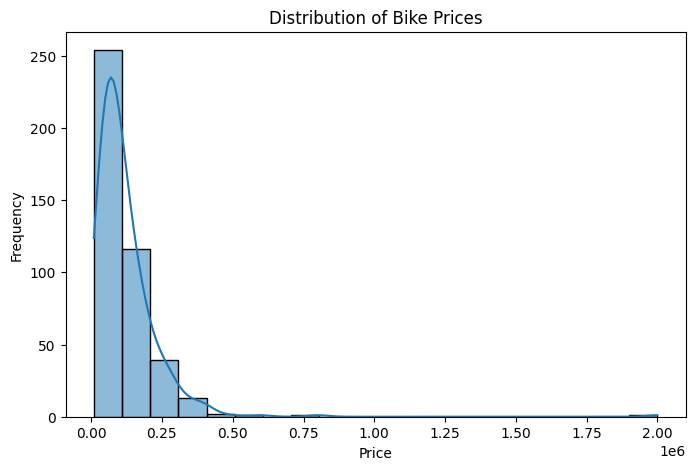

In [32]:
# Distribution of Bike Prices
plt.figure(figsize=(8,5))
sns.histplot(df["Price"],bins=20,kde=True)

plt.title("Distribution of Bike Prices")
plt.ylabel("Frequency")

plt.show()

* The distribution of bike prices is positively skewed, with most bikes falling in the lower to middle price range. A few premium bikes have significantly higher prices, creating a long right tail.

In [33]:
#Box Plot of Bike Prices
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Boxplot of Bike Prices")
plt.xlabel("Price")
    
plt.show()

SyntaxError: unterminated string literal (detected at line 7) (1520811408.py, line 7)

* The box plot shows a few high priced outliers, representing premium motorcycle models. These values are valid observations and have been retained.

In [ ]:
#Violin Plot of Bike Prices
plt.figure(figsize=(8,2))
sns.violinplot(x=df["Price"])
plt.title("Violin Plot of Bike Prices")
plt.show()

* The violin plot indicates that most bike prices are concentrated in the lower price range, while the density gradually decreases as prices increase.

In [ ]:
#Distribution of Model Year
plt.figure(figsize=(8,5))
sns.histplot(df["Model Year"], bins=15, kde=True)
plt.title("Distribution of Model Year")
plt.xlabel("Model Year")
plt.ylabel("Frequency")
plt.show()

* Most listed bikes belong to recent model years, indicating that newer bikes are more frequently available in the used bike market.

In [ ]:
#Violin Plot of Kilometers Driven
plt.figure(figsize=(8,2))
sns.violinplot(x=df["Kilometers Run"])
plt.title("Violin Plot of Kilometers Run")
plt.show()

* Most bikes have moderate mileage, while only a few have very high kilometers driven, indicating a wide range of usage among the listed bikes.

In [ ]:
# Percentage Distribution of Brand
(df["Brand"].value_counts(normalize=True) * 100).round(2)

In [ ]:
#Count Plot of Bike Brands
plt.figure(figsize=(12,6))
sns.countplot(
    y=df["Brand"],
    order=df["Brand"].value_counts().index
)
plt.title("Number of Bikes by Brand")
plt.show()

* Royal Enfield have significantly more listings than others, indicating its popularity in the used bike market.

In [ ]:
#Percentage Distribution of Ownership
(df["Owners"].value_counts(normalize=True) * 100).round(2)

In [ ]:
#Frequency Distribution of Ownership
plt.figure(figsize=(5,4))
sns.countplot(x="Owners", data=df)
plt.title("Ownership Distribution")
plt.show()

* Most listed bikes are single owner vehicles, suggesting that sellers generally offer relatively well maintained bikes.

In [ ]:
#Pie Chart of Listing Type
l_counts = df["Listing Type"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(l_counts,
        labels=l_counts.index,
        autopct="%1.1f%%")
plt.title("Listing Type Distribution")
plt.show()

* The dataset contains both Basic and Premium listings, allowing comparison between different listing categories.

## Bivariate Analysis 

In [ ]:
# Relationship Between Price and Kilometers Driven
plt.figure(figsize=(8,5))
sns.scatterplot(x="Kilometers Run", y="Price", data=df)
plt.title("Price vs Kilometers Run")
plt.show()

* There is a general tendency for bike prices to decrease as the kilometers run increases, although the relationship is not perfectly linear.

In [ ]:
# Relationship Between Price and Model Year
plt.figure(figsize=(8,5))
sns.scatterplot(x="Model Year", y="Price", data=df)
plt.title("Price vs Model Year")
plt.show()

* Newer model bikes generally have higher selling prices than older models

In [ ]:
#Price Distribution by Brand
plt.figure(figsize=(14,6))
sns.boxplot(x="Brand", y="Price", data=df)
plt.xticks(rotation=90)
plt.title("Price by Brand")
plt.show()

* Premium brands tend to have higher median prices than economy brands.

In [ ]:
# Price Distribution by Listing Type
plt.figure(figsize=(6,5))
sns.boxplot(x="Listing Type", y="Price", data=df)
plt.title("Price by Listing Type")
plt.show()

* Premium listings generally have higher prices than basic listings.

In [ ]:
# Price Distribution by Ownership
plt.figure(figsize=(6,5))
sns.boxplot(x="Owners", y="Price", data=df)
plt.title("Price by Ownership")
plt.show()

* Single owner bikes generally command higher prices compared to bikes with multiple owners.

## Multivariate Analysis

In [ ]:
#Average Selling Price by Brand
brand_price = df.groupby("Brand")["Price"].mean().sort_values(ascending=False)
brand_price

* Premium brands such as BMW and Triumph have the highest average selling prices.
Budget brands like Hero and Honda have comparatively lower average resale prices.

In [ ]:
#Average Price by Listing Type
df.groupby("Listing Type")["Price"].mean()

* Premium listings have a higher average selling price compared to basic listings.

In [ ]:
#Average Price by Brand and Ownership
pivot = pd.pivot_table(
    df,
    values="Price",
    index="Brand",
    columns="Listing Type",
    aggfunc="mean"
)

pivot

* The average resale price varies across both brand and ownership categories.
* Single Owner bikes generally have higher average prices because they are often perceived as better maintained.

In [ ]:
#Listing Type vs Ownership
pd.crosstab(df["Owners"], df["Listing Type"])

* Premium Listings contain relatively more well maintained bikes compared to other ownership categories.
* The ownership pattern is consistent across listing types, with Single Owner bikes dominating the market.

In [ ]:
# Correlation Analysis of Numerical Features
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Price","Model Year","Kilometers Run","Owners"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

* The heatmap shows the strength and direction of relationships among numerical variables. Price generally has a positive correlation with Model Year and a negative correlation with Kilometers Run.
* No extremely strong correlations are observed, suggesting that bike prices are influenced by multiple factors rather than a single feature.

## Conclusion
* This project analyzed the factors affecting the resale prices of used bikes using data scraped from the Bikes4Sale website.
* Data cleaning improved the quality of the dataset by handling missing values, duplicates, incorrect formats, and outliers.
* Most listed bikes belong to popular commuter brands such as Hero, Honda, Royal Enfield, and TVS.
* Single Owner bikes account for the majority of listings, indicating a preference for well maintained vehicles in the used bike market.
* Premium Listings generally have higher selling prices than Regular Listings.
* Newer model bikes with lower kilometers driven tend to have higher resale values.
* Bikes with larger engine capacities generally command higher prices, reflecting their premium positioning.
* Correlation analysis showed that price is positively associated with model year and engine capacity, while it is negatively associated with kilometers driven.
* Overall, Brand, Model Year,  Kilometers Driven, Ownership, and Listing Type are the key factors influencing the resale price of used bikes.
* The insights obtained from this analysis can help buyers make informed purchasing decisions and assist sellers in pricing their bikes more accurately.

In [5]:
n='kirthi'
x={}
for i in n:
    if i in x:
        x[i]=x[i]+1
    else:
        x[i]=1
print(x)

{'k': 1, 'i': 2, 'r': 1, 't': 1, 'h': 1}


In [7]:
def add(a,b):
   return (a+b)
add(2,3)

5

In [8]:
a=[1,2,3,4,5]
b=a.copy()
a.append(6)

In [9]:
a

[1, 2, 3, 4, 5, 6]

In [10]:
b

[1, 2, 3, 4, 5]

In [11]:
b.append(7)

In [12]:
b

[1, 2, 3, 4, 5, 7]

In [13]:
a

[1, 2, 3, 4, 5, 6]

In [ ]:
select max(salary) from emp
where salary<(select max(salary) from emp)